In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pickle
from collections import OrderedDict
import pandas as pd

In [5]:
def readData(path,samples):
    selectedNewContig = {}
    sampleWithFusions = 0
    for sample in samples:
        if 'Sample_' in sample:
            resPath = f"{path}/{sample}/call_fusion_virus/HPVfusionPointContig.txt"
            resdicPath = f"{path}/{sample}/call_fusion_virus/filteredSelectedContig.pickle"
            #print(resPath)
            if not os.path.isfile(resdicPath):
                print(sample)
            else:
                with open(resdicPath,'rb') as resDicFile:
                    resDic = pickle.load(resDicFile)

                    selectedNewContig[sample] = resDic
                sampleWithFusions += 1
    return selectedNewContig
    #             else:
    #                 print(sample)


In [8]:
#sample insterested SOP-13A, B, C; SOP-11A, B, C; SOP-63A, B
sample_list = ['Sample_2920-CB-6',
'Sample_2920-CB-7',
'Sample_2920-CB-8',
'Sample_2920-CB-14',
'Sample_2920-CB-15',
'Sample_2920-CB-16',
'Sample_2789-CB-60',
'Sample_2789-CB-61']
path = '/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res'
all_dic = readData(path,sample_list)

In [9]:
all_dic

{'Sample_2920-CB-6': {'20.24821024': [['Contig1',
    [[139, '172S139M', 0, [(4, 172), (0, 139)]]],
    [[161, '150S161M', 24821023, [(4, 150), (0, 161)]]],
    311,
    16,
    0],
   ['Contig2',
    [[126, '126M117S', 3331, [(0, 126), (4, 117)]]],
    [[47, '47M196S', 24820969, [(0, 47), (4, 196)]]],
    243,
    3,
    3457,
    'lowConfidence']],
  '4.165363130': [['Contig1',
    [[61, '61M48S', 888, [(0, 61), (4, 48)]]],
    [[49, '49M60S', 165363129, [(0, 49), (4, 60)]]],
    109,
    5,
    949,
    'lowConfidence']],
  '3.102836408': [['Contig1',
    [[90, '90M43S', 3422, [(0, 90), (4, 43)]]],
    [[40, '93S40M', 102836414, [(4, 93), (0, 40)]]],
    133,
    3,
    3512,
    'lowConfidence']],
  '9.5890106': [['Contig1',
    [[124, '124M67S', 2050, [(0, 124), (4, 67)]]],
    [[79, '112S79M', 5890105, [(4, 112), (0, 79)]]],
    191,
    3,
    2174,
    'lowConfidence']],
  'X.72339450': [['Contig1',
    [[47, '47M43S', 883, [(0, 47), (4, 43)]]],
    [[47, '43S47M', 72339434, [(

In [45]:
#distribution plot
readDepth = "/home/wenjingu/remillsscr/HPV_fusion/targeted_exom/our_pip/newVersion/normReadDepth/readDepthAll.txt"
readNum = "/home/wenjingu/remillsscr/HPV_fusion/targeted_exom/our_pip/newVersion/normReadDepth/readNumAll.txt"
depthDic = {}
geneLengthDic = {}
geneNumberDic = {}
with open(readDepth) as input1:
    rows = input1.read().rstrip().split('\n')
    for row in rows:
        gene = row.split('\t')[0]
        depthList = row.split('\t')[1].split(',')
        depthDic[gene] = depthList
        lengthList = row.split('\t')[2].split(',')
        geneLengthDic[gene] = lengthList
with open(readNum) as input2:
    rows = input2.read().rstrip().split('\n')
    for row in rows:
        gene = row.split('\t')[0]
        readNumList = row.split('\t')[1]
        geneNumberDic[gene] = readNumList
        

In [46]:
depthDic

{'103101': ['623589', '139013', '1348129', '1024818'],
 '97009': ['257973', '34712', '225050', '414913'],
 '88109': ['646713', '151889', '1025841', '1032095'],
 '2920-CB-34': ['53809', '5883', '28634', '38068'],
 '2789-CB-46': ['883443', '178728', '705857', '851467'],
 '2655-CB-52': ['596370', '142291', '159286', '371007'],
 '2655-CB-40': ['1503150', '330156', '957503', '1455042'],
 '92430': ['410825', '97695', '613493', '658159'],
 '2655-CB-9': ['678768', '141987', '306280', '520351'],
 '152-CB-27': ['1240486', '304494', '986861', '1373677'],
 '2789-CB-20': ['219933', '38032', '187582', '257138'],
 '2655-CB-23': ['960906', '227510', '518277', '789895'],
 '83024': ['225801', '62858', '532692', '504139'],
 '2920-CB-98': ['23234', '5688', '24581', '36482'],
 '2655-CB-38': ['1695796', '406623', '953896', '1676484'],
 '152-CB-90': ['949686', '205028', '781322', '1218714'],
 '115305': ['1532025', '355305', '1447650', '1683176'],
 '6670-CB-64': ['1027387', '109997', '550422', '818963'],
 '66

In [20]:
MAP2K4 = {}
for gene in depthDic:
    if int(geneLengthDic[gene][2]) == 0 or int(geneNumberDic[gene]) == 0:
        print(gene,int(depthDic[gene][2]),int(geneLengthDic[gene][2]),int(geneNumberDic[gene]))
    else:
        MAP2K4['Sample_'+gene] = int(depthDic[gene][2])/int(geneLengthDic[gene][2])

In [11]:
#hpv gene site PDX
ncbi_hpvDic = {'E1': [['1', '1950']],
 'E2': [['1892', '2989']],
 'E5': [['2986', '3237']],
 'E6': [['7125', '7601']],
 'E7': [['7604', '7900']],
 'L1': [['4775', '6292']],
 'L2': [['3373', '4794']],
 'E1^E4': [['1', '2756']],
 'E2BS: E2 binding site': [['6589', '6600'],['6996','7007'],['7092', '7103'],['7077','7088']],
 'URR': [['6293', '7124']]}

In [40]:
def readDepth(sample,depthDic):
    depthPath = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/readDepth/{sample}_read_depth.txt'
    x = []
    y = []
    with open(depthPath) as inputFile:
        for row in inputFile:
            chro = row.split('\t')[0]
            if chro == 'gi|333031|lcl|HPV16REF.1|':
                x.append(int(row.split('\t')[1]))
                y.append(int(row.split('\t')[2]))
    x = np.array(x)
    y = np.array(y)
    y = 2*y/MAP2K4[sample]
    depthDic[sample] = [x,y]
    return depthDic


In [41]:
HPVdepthDic = {}
for sample in sample_list:
    HPVdepthDic = readDepth(sample,HPVdepthDic)

In [42]:
HPVdepthDic

{'Sample_2920-CB-6': [array([   1,    2,    3, ..., 7904, 7905, 7906]),
  array([32.53747055, 32.93793173, 33.13816231, ..., 27.73193644,
         27.53170585, 26.93101409])],
 'Sample_2920-CB-7': [array([   1,    2,    3, ..., 7904, 7905, 7906]),
  array([24.4008157 , 25.05587115, 26.03845434, ..., 16.54015024,
         16.54015024, 16.54015024])],
 'Sample_2920-CB-8': [array([   1,    2,    3, ..., 7904, 7905, 7906]),
  array([60.4684271 , 62.30080367, 63.16877153, ..., 45.80941447,
         45.23076923, 44.84500574])],
 'Sample_2920-CB-14': [array([   1,    2,    3, ..., 7904, 7905, 7906]),
  array([73.21308062, 75.10768899, 75.91966401, ..., 79.70888075,
         79.16756407, 78.76157657])],
 'Sample_2920-CB-15': [array([   1,    2,    3, ..., 7904, 7905, 7906]),
  array([27.95801916, 28.94477277, 29.60260852, ..., 31.57611575,
         31.46647646, 31.24719788])],
 'Sample_2920-CB-16': [array([   1,    2,    3, ..., 7904, 7905, 7906]),
  array([719.45820078, 737.67448745, 748.3999

In [43]:
hpv16ArrowDic = {}
for each in all_dic:
    hpv16ArrowDic[each] = []

for each in all_dic:    
    for site in all_dic[each]:
        for contig in all_dic[each][site]:
            if contig[-1] != 'lowConfidence':
                hpvsite = contig[-1]
            else:
                hpvsite = contig[-2]
            #print(hpvsite)
            hpv16ArrowDic[each].append(int(hpvsite))
            
hpv16ArrowDicNew = {}
for sample in hpv16ArrowDic:
    hpv16ArrowDicNew[sample] = []
    for site in hpv16ArrowDic[sample]:
        if sample in HPVdepthDic:
            if site == 0:
                print(sample,HPVdepthDic[sample][1])
                site = max(HPVdepthDic[sample][1])

            print(site,sample)
            i = 0
            flag = False
            for eachBase in HPVdepthDic[sample][0]:
                if site-1 == eachBase:
                    y = HPVdepthDic[sample][1][i]
                    print(y)
                    flag = True
                i += 1
            if flag == False:
                y = 0
            hpv16ArrowDicNew[sample].append(y)

Sample_2920-CB-6 [32.53747055 32.93793173 33.13816231 ... 27.73193644 27.53170585
 26.93101409]
58.26710110782495 Sample_2920-CB-6
3457 Sample_2920-CB-6
52.26018346784299
949 Sample_2920-CB-6
51.4592611158454
3512 Sample_2920-CB-6
35.84127525189232
2174 Sample_2920-CB-6
48.656032883853825
930 Sample_2920-CB-6
55.76421875783247
5750 Sample_2920-CB-6
27.03112937991879
1359 Sample_2920-CB-6
51.7596069978445
892 Sample_2920-CB-6
52.86087523184119
Sample_2920-CB-6 [32.53747055 32.93793173 33.13816231 ... 27.73193644 27.53170585
 26.93101409]
58.26710110782495 Sample_2920-CB-6
3457 Sample_2920-CB-6
52.26018346784299
3913 Sample_2920-CB-6
28.43274349591458
940 Sample_2920-CB-6
52.76075993784149
5294 Sample_2920-CB-6
22.12547997393353
3278 Sample_2920-CB-6
39.745771717880594
3914 Sample_2920-CB-7
33.08030047651747
Sample_2920-CB-7 [24.4008157  25.05587115 26.03845434 ... 16.54015024 16.54015024
 16.54015024]
66.48812868052521 Sample_2920-CB-7
2135 Sample_2920-CB-7
57.153588447052456
4395 Sampl

4184 Sample_2920-CB-16
353.25976493460587
6100 Sample_2920-CB-16
934.3082361258395
4619 Sample_2920-CB-16
965.973930717568
945 Sample_2920-CB-16
1401.6325998586071
1395 Sample_2920-CB-16
1380.862628137151
6879 Sample_2920-CB-16
1097.573833510074
1226 Sample_2920-CB-16
1131.6229674796748
4192 Sample_2920-CB-16
605.393601979498
3912 Sample_2920-CB-16
1329.107944503358
7270 Sample_2920-CB-16
646.4228084128667
2126 Sample_2920-CB-16
1381.203119476847
2384 Sample_2920-CB-16
987.4248851184163
4451 Sample_2920-CB-16
939.9263432308236
1398 Sample_2920-CB-16
1344.0895634499823
2051 Sample_2920-CB-16
1082.59221456345
7676 Sample_2920-CB-16
1091.4449893955461
2162 Sample_2920-CB-16
1305.2735507246377
5941 Sample_2920-CB-16
1184.2288794627077
4205 Sample_2920-CB-16
760.3171615411806
1381 Sample_2920-CB-16
1480.6265906680806
3898 Sample_2920-CB-16
1316.3395192647579
4325 Sample_2920-CB-16
1176.3975786496994
949 Sample_2920-CB-16
1434.4900141392718
1310 Sample_2920-CB-16
1421.8918345705197
4602 Samp

In [51]:
colorDic = {}
for gene in ncbi_hpvDic:
    colorDic[gene] = list(np.random.rand(3,))

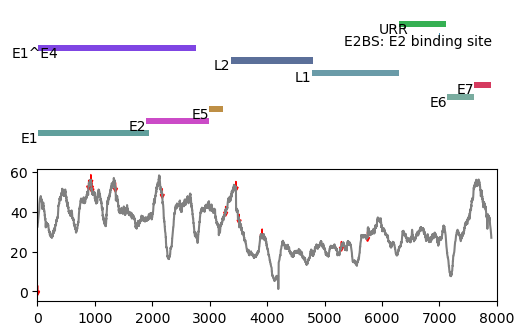

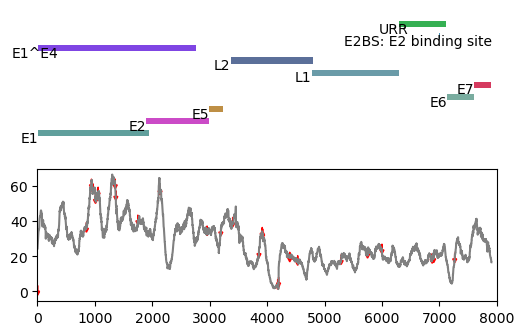

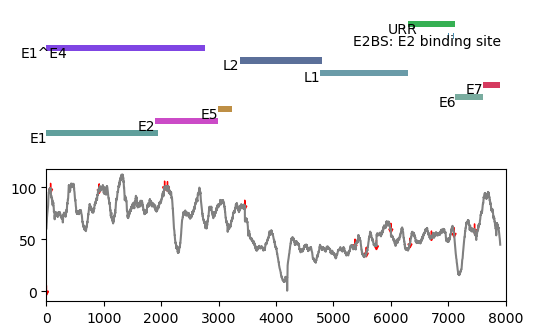

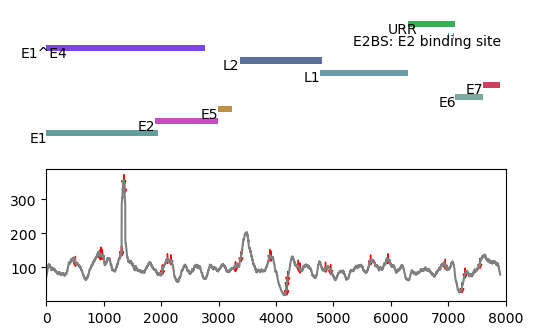

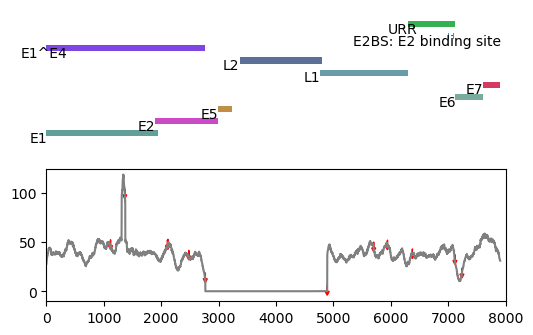

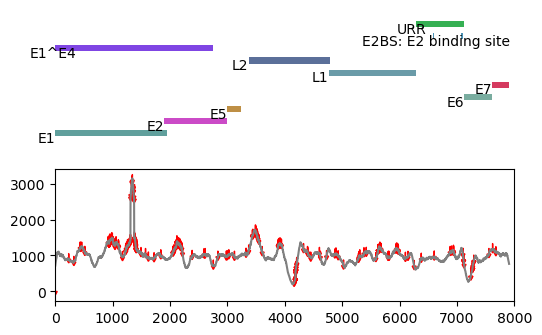

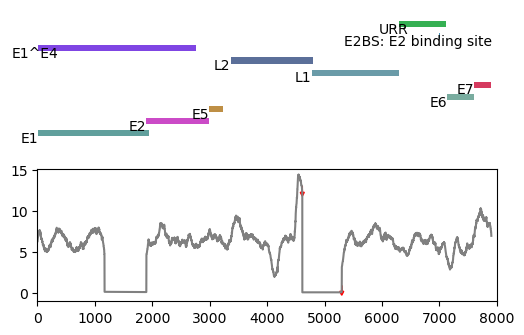

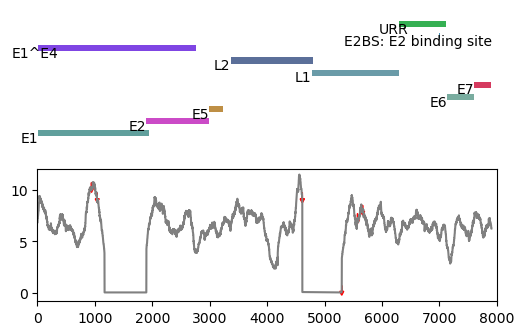

In [56]:
for sample in sample_list:
    fig = plt.figure(figsize = [10,10])
    gs = fig.add_gridspec(5, 5, hspace=0.2,wspace = 0.1)
    ax4 = fig.add_subplot(gs[1:2,0:3])
    i = 0       
    for hpvGene in ncbi_hpvDic:
        xlist = []
        for slot in ncbi_hpvDic[hpvGene]:
            step = 10
            space = 10
            x1 = int(slot[0])
            xlist.append(x1)
            y1 = 0 + i*step + i*space
            end = int(slot[1])

            rect = patches.Rectangle((x1,y1),end-x1,step,\
                                     facecolor=colorDic[hpvGene],alpha = 0.8)
            ax4.add_patch(rect)
        #ax4.legend(hpvGeneColor.keys())
        ax4.text(min(xlist) - 200-50*len(hpvGene),y1 - space,hpvGene)
        i += 1
    ax4.set_xlim(0,8000)
    ax4.set_ylim(0-10,y1 + space + step + 10)
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.spines['bottom'].set_visible(False)
    ax4.spines['left'].set_visible(False)

    #add readdepth
    ax5 = fig.add_subplot(gs[2:3,0:3])
    ax5.plot(HPVdepthDic[sample][0],HPVdepthDic[sample][1],color='grey')

    i = 0
    if sample in hpv16ArrowDic:
        for each in hpv16ArrowDic[sample]:
            if max(HPVdepthDic[sample][1]) > 10000:
                ax5.arrow(x = each,y = hpv16ArrowDicNew[sample][i] + max(HPVdepthDic[sample][1])/20,
                  dx = 0, dy = -max(HPVdepthDic[sample][1])/20,color = 'r',width = 2,head_width = max(HPVdepthDic[sample][1])/500,\
                      head_length = max(HPVdepthDic[sample][1])/30)
            else:
               
                ax5.arrow(x = each,y = hpv16ArrowDicNew[sample][i] + max(HPVdepthDic[sample][1])/20,
                  dx = 0, dy = -max(HPVdepthDic[sample][1])/20,color = 'r',width = 2,head_width = 70,\
                      head_length = max(HPVdepthDic[sample][1])/30)
            i += 1
    ax5.set_xlim(0,8000)
    savePath = f'/home/wenjingu/remillsscr/HPV_fusion/targeted_exom/our_pip/newVersion/analysis/script_for_big_paper/Figure6/junctionPlots/{sample}.pdf'
    plt.savefig(savePath)



In [45]:
sample1Dic

{'Sample_2655-CB-91': [[6794, 6519, 6148, 6951],
  [6952, 6148, 6520, 6794],
  [227, 62, 56, 203],
  [227, 62, 56, 203]],
 'Sample_2655-CB-90': [[6794,
   6951,
   677,
   7304,
   2368,
   7618,
   6373,
   3899,
   4246,
   4779,
   6164,
   6148,
   6519],
  [6952,
   6794,
   7304,
   678,
   7901,
   6165,
   4779,
   4246,
   3899,
   6373,
   7619,
   6520,
   6148],
  [350, 315, 1, 1, 1, 1, 1, 2, 2, 1, 1, 119, 129],
  [350, 315, 1, 1, 1, 1, 1, 2, 2, 1, 1, 119, 129]]}

In [175]:
all_dic['Sample_2655-CB-86']

{'3.189604181': [['Contig1',
   [[427, '427M318S', 7479, [(0, 427), (4, 318)]]],
   [[160, '441S160M144S', 189604180, [(4, 441), (0, 160), (4, 144)]],
    [144, '601H144M', 189607128, [(5, 601), (0, 144)]]],
   745,
   94,
   7906]]}

In [145]:
hpv16ArrowDicNew['Sample_2655-CB-94']

[0, 58]

In [27]:
colorDic = {}
for gene in ncbi_hpvDic:
    colorDic[gene] = list(np.random.rand(3,))